In [1]:
import numpy as np
import scarf

scarf.set_verbosity('WARNING')

scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
normalized = ds.run_normalization(feat_key='hvgs')
pca = ds.run_pca(normalized, dims=15)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=11)
ds.build_connectivity_map(neighbors)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)
ds.run_marker_search(group_key='RNA_leiden_cluster', gene_batch_size=100)

In [2]:
markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers.head(10)

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.67349,0.04322,0.00262,0.24067,0.02126,16.50967,5.636896e-112,4118
1,1,TSHZ2,0.58156,0.07293,0.01026,0.32883,0.04812,7.10882,1.466001e-126,11958
2,1,ANKRD55,0.58125,0.02205,0.00109,0.14932,0.00895,20.18654,1.668800e-74,3609
3,1,FHIT,0.54371,0.14391,0.01379,0.61795,0.09511,10.43786,7.085965e-287,2632
4,1,AC005842.1,0.53671,0.02563,0.00265,0.16044,0.01940,9.66252,3.791161e-64,8111
5,1,CHRM3-AS2,0.52845,0.06914,0.00762,0.38761,0.05595,9.07518,3.908728e-158,1366
6,1,TCEA3,0.50144,0.03177,0.00415,0.21048,0.03282,7.65532,6.177618e-76,213
7,1,CMTM8,0.47798,0.04741,0.00939,0.30342,0.07199,5.04773,1.159086e-86,2406
8,1,MAN1C1,0.45000,0.05092,0.00954,0.31771,0.08206,5.33843,3.202444e-88,246
9,1,EPHX2,0.44780,0.06755,0.00972,0.38602,0.07199,6.95361,8.947101e-137,5931


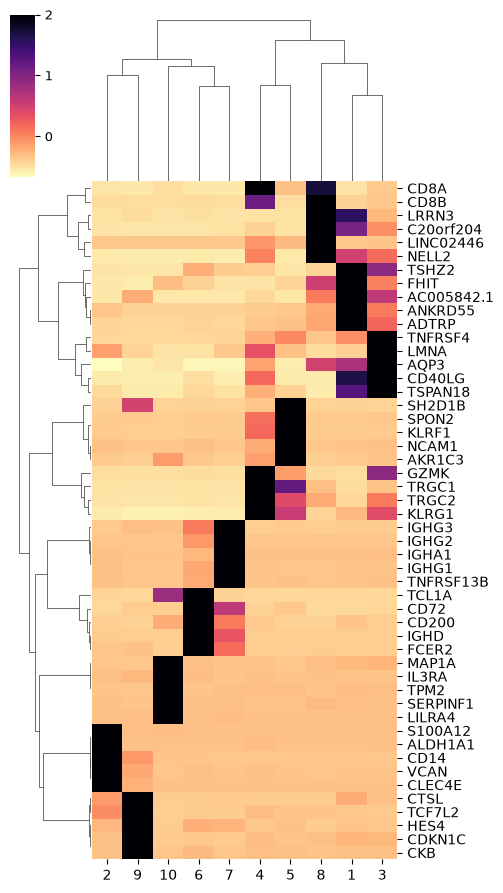

PlotResult(axes=4, tables=2, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9),
)

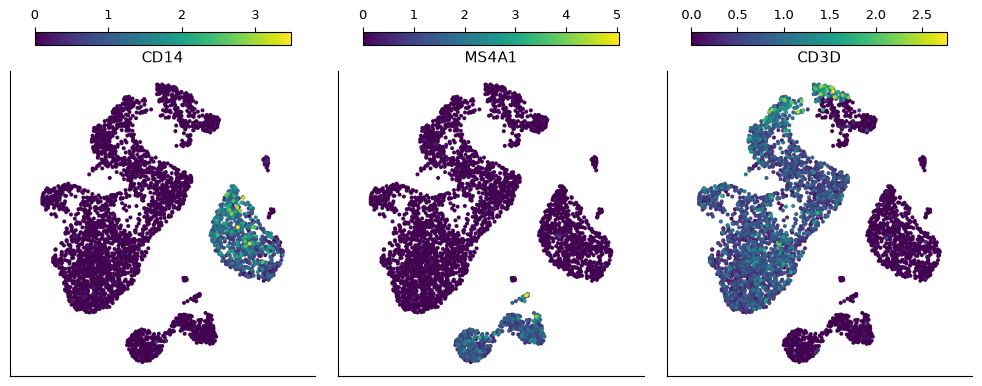

PlotResult(axes=3, tables=0, legends=3, scales=3, owns_figure=True, rendered=True)

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)

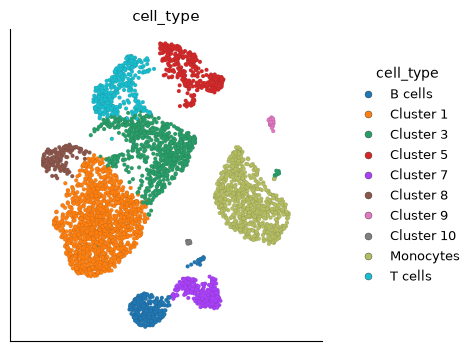

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [5]:
cluster_ids = ds.cells.fetch_all('RNA_leiden_cluster')
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)

markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)

label_map = {c: f'Cluster {c}' for c in unique}
for gene, name in [('CD14', 'Monocytes'), ('MS4A1', 'B cells'), ('CD3D', 'T cells')]:
    hit = markers[markers['feature_name'].astype(str) == gene]
    if hit.empty:
        continue
    cid = str(hit.sort_values('score', ascending=False).iloc[0]['group_id'])
    label_map[cid] = name

labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name='cell_type', values=labels, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cell_type',
)

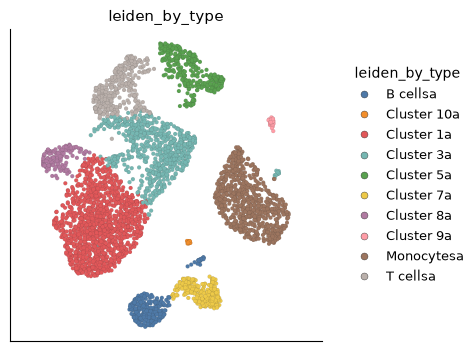

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [6]:
ds.smart_label(
    to_relabel='RNA_leiden_cluster',
    base_label='cell_type',
    new_col_name='leiden_by_type',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='leiden_by_type',
)

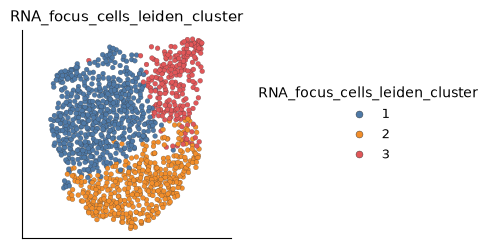

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [7]:
clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I',
)['RNA_leiden_cluster'].astype(str)
focus = str(clusters.value_counts().index[0])
subset = np.array([str(c) == focus for c in ds.cells.fetch_all('RNA_leiden_cluster')])
active = ds.cells.fetch_all('I').astype(bool)
ds.cells.insert('focus_cells', active & subset, overwrite=True)
# Feature keys are resolved as <cell_key>__<feat_key>. Recompute HVGs for the subset.
ds.mark_hvgs(
    cell_key='focus_cells',
    min_cells=10,
    top_n=500,
    show_plot=False,
)

normalized = ds.run_normalization(cell_key='focus_cells', feat_key='hvgs')
pca = ds.run_pca(normalized, dims=15)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=11)
ds.build_connectivity_map(neighbors)
ds.run_umap(
    cell_key='focus_cells',
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label='UMAP',
)
ds.run_leiden_clustering(
    cell_key='focus_cells',
    resolution=0.4,
    label='leiden_cluster',
)
# With cell_key != 'I', columns are RNA_<cell_key>_<label>
ds.plots.embedding(
    layout_key='RNA_focus_cells_UMAP',
    color_by='RNA_focus_cells_leiden_cluster',
    cell_key='focus_cells',
)